# 4. projekt (minta)


# Feladat

Oldja meg (közelítő) `hatványsor` módszerrel a következő kezdeti érték feladatot:
\begin{gather*}
    y'' - 2y' - y = 1+t\\
    y(0)=2\\
    y'(0)=-\frac{2}{10}\\
\end{gather*}

---

\begin{gather*}
y(2.9)=?
\end{gather*}

A megoldást számolja ki $5.,10.,20.,30.$ rendű tagig és hasonlítsa össze ```ode45``` által számolttal!


# Megoldás

* Írjuk fel a jobboldalt hatványsor alakban.
  (Itt most ez könnyű: $\sum_{k\ge0}b_k t^k,\ \ b_k=[1,1,0,0,...]$)
* Keressük a megoldást $f(t)=\sum_{k\ge0} a_k t^k$  (hatványsor) alakban.
* A kezdeti feltételek meghatározzák $a_0,a_1$-et
* Helyettesítsük be $f$-et az egyenletbe (baloldal)
* Vessük össze a baloldal együtthatóit a jobboldal együtthatóival.
  * megfelelő átindexelést alkalmazva:
  * $f'(t)=\sum_{k=1} ka_{k}t^{k-1} = \sum_{k=0} (k+1)a_{k+1}t^k$
  * $f''(t)=\sum_{k=1} (k+1)ka_{k+1}t^{k-1} = \sum_{k=0} (k+2)(k+1)a_{k+2}t^k$
* Az $a_k$ sorozatra kapott összefüggések segítségével $f$-et akárhány tagig ki tudjuk számolni
* (Zárt alakot is kereshetünk az $a_k$ sorozatra - ez *általában* nehéz és nem is célunk.)


\begin{gather*}
a_0=y(0)=2 \\
a_1=y'(0)=-\frac{2}{10} \\
\end{gather*}

\begin{gather*}
f''(t)=\sum_{k\ge2} a_{k}k(k-1)t^{k-2}=
\sum_{k\ge0} a_{k+2}(k+2)(k+1)t^{k}\\
-2f'(t)=\sum_{k\ge1} -2a_{k}k t^{k-1} =
\sum_{k\ge0} -2a_{k+1}(k+1) t^{k}\\
-f(t) = \sum_{k\ge0} -a_{k}t^k
\end{gather*}

A rekurzió általános alakja $k\ge 0$ esetben:
\begin{gather*}
a_{k+2}(k+2)(k+1)-2a_{k+1}(k+1)-a_k = b_k \\
a_{k+2}=\frac{b_k+2a_{k+1}(k+1)+a_k}{(k+2)(k+1)}
\end{gather*}



# Matlab

Létrehozunk egy polinomot - a megoldás egy részletösszegét - a fenti rekurzionak megfelelő együtthatókkal, stb, stb...

In [1]:
%%file hatvsor.m

% a függvény csak az adott feladatot egy N-fokú hatványsoros közelítését (p-polinom) adja vissza
function p=hatvsor(N,y0,dy0)
  d = 1; % ezzel érhetjük el hogy egy az egyben a levezetett formulát használhassuk
  a=zeros(N+1,1);
  a(0+d)=y0; 
  a(1+d)=dy0; 
  
  b=zeros(N+1,1);
  b(0+d)=1;
  b(1+d)=1;
  
  
  % a rekurzióban szereplő a(k+2)-t számoljuk
  for k=0:N-2
    a(k+2+d)=(b(k+d)+2*a(k+1+d)*(k+1)+a(k+d))/((k+2)*(k+1));
  end
  p = a(end:-1:1); % az algo novekvő fokszámmal dolgozik
end

Created file '/home/nosy/Downloads/mm2_projektek/p4/hatvsor.m'.


In [11]:
% számolások

% kezdeti feltételek
y0=2; dy0=-0.2;
t0=0; tv=2.9;


t = linspace(t0, tv); % mindegyiknel ezt hasznalja

p5 = hatvsor(5,y0,dy0);
y5 = polyval(p5, t);

p10 = hatvsor(10,y0,dy0);
y10 = polyval(p10, t);

% hasonlóan mint a projekt 2-ben:
f=@(t,y,dy) t + 1 + y + 2*dy;
F=@(t,v) [v(2); f(t,v(1),v(2))]; 

Y=[y0;dy0];

[tode,yode]=ode45(F,[t0;tv],Y);

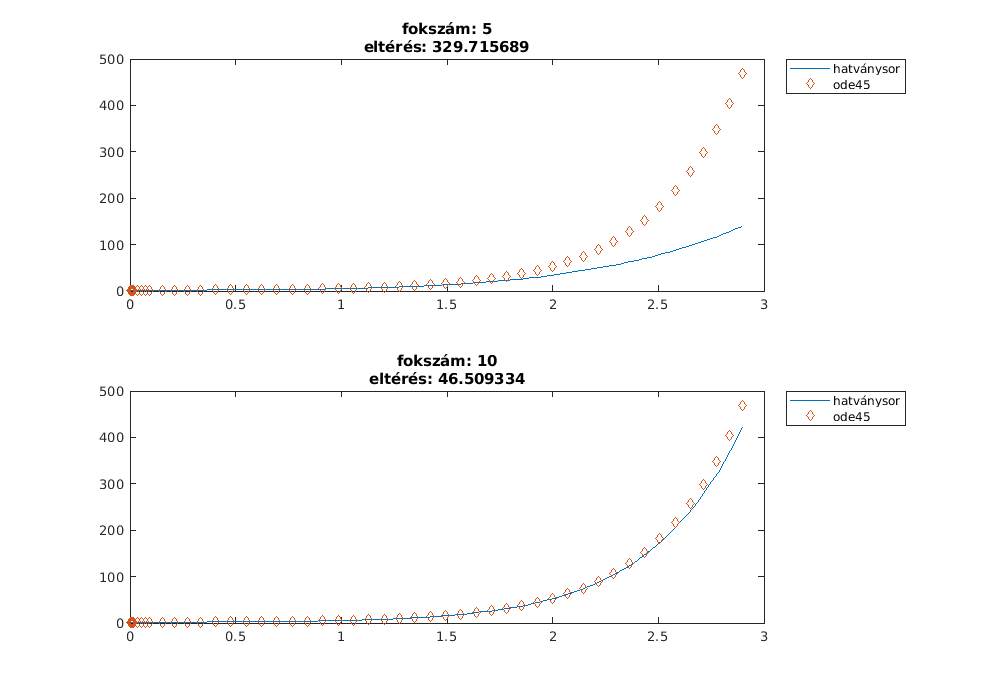

In [13]:
%plot -s 1000,700

% külön ábrák hogy lássuk a becslés "javulását"


subplot(2,1,1);
plot(t, y5, tode, yode(:,1),'d');
legend("hatványsor", "ode45", "location", "northeastoutside");
title(sprintf("fokszám: 5\neltérés: %.6f",abs(yode(end,1)-y5(end))));

subplot(2,1,2);
plot(t, y10, tode, yode(:,1),'d');
legend("hatványsor", "ode45", "location", "northeastoutside")
title(sprintf("fokszám: 10\neltérés: %.6f",abs(yode(end,1)-y10(end))));

